#EXPERIMENT 3: STOCK PRICE PREDICTION USING REGRESSION

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from google.colab import drive


#Develop a regression model to predict stock prices based on historical stock-related features.
#Since stock price is a continuous numeric value, this is a Regression problem.

#Problem Definition
↓
#Data Understanding
↓
#Preprocessing
↓
#Train–Test Split
↓
#Regression Model
↓
#Training
↓
#Prediction
↓
#Evaluation (MSE, R²)
↓
#Graphical Analysis


#Step 1: Data Understanding
#Each row represents stock data for a particular time period
#Target Variable (y):
#Price
#Input Features (X):
#Stock-related numerical attributes (Open, High, Low, Volume, etc.)

In [21]:
df = pd.read_csv("/content/drive/MyDrive/AML_Lab/EXP3/stock_price_with_price_column.csv")
df.head()

,Date,Stock,Open,High,Low,Close,Volume,Price
0,2020-01-01,AAPL,173.80,174.75,173.68,174.43,8204212,174.286667
1,2020-01-02,AAPL,176.01,177.59,174.07,177.55,2766891,176.403333
2,2020-01-03,AAPL,177.57,178.37,176.62,176.71,5721339,177.233333
3,2020-01-06,AAPL,176.01,177.58,171.33,171.73,9242680,173.546667
4,2020-01-07,AAPL,171.85,172.20,170.69,170.82,4416664,171.236667


#Step 2: Data Preprocessing
#Check for missing values
#Remove non-numeric or identifier columns if present

In [25]:
data = pd.read_csv("/content/drive/MyDrive/AML_Lab/EXP3/stock_price_with_price_column.csv")
data['Lag_1'] = data['Price'].shift(1)
data['Lag_2'] = data['Price'].shift(2)
data['Lag_3'] = data['Price'].shift(3)
data = data.dropna()


#Step 3: Feature–Target Split
#X → input features
#y → stock price

In [ ]:
X = df[['Lag_1', 'Lag_2', 'Lag_3']]
y = df['Price']



#Step 4: Train–Test Split
#Training data → 80%
#Testing data → 20%

In [26]:
X = data[['Lag_1', 'Lag_2', 'Lag_3']]
y = data['Price']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


#Step 5: Choose the Regression Model

#Linear Regression is used to model the relationship between stock features and price.

In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()


#Step 6: Train the Model
#The model learns coefficients by minimizing Mean Squared Error (MSE).

In [28]:
model.fit(X_train, y_train)


LinearRegression()

#Step 7: Make Predictions

In [29]:
y_pred = model.predict(X_test)


#Step 8: Model Evaluation
#Metrics Used:

-Mean Squared Error (MSE)

-R² Score

In [30]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)


Mean Squared Error: 4.834189149607577


In [31]:
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.9792163044358004


#Step 9: Graphical Evaluation
-Actual vs Predicted Stock Prices with Reference Line

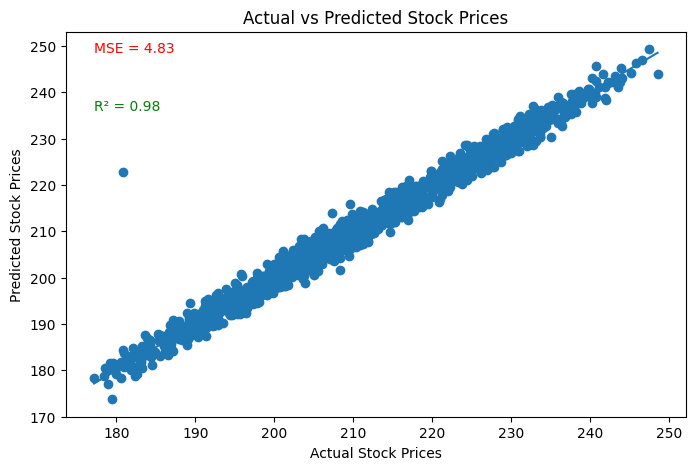

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.text(y_test.min(), y_test.max(),
         f"MSE = {mse:.2f}", color='red')

plt.text(y_test.min(), y_test.max()*0.95,
         f"R² = {r2:.2f}", color='green')

plt.xlabel("Actual Stock Prices")
plt.ylabel("Predicted Stock Prices")
plt.title("Actual vs Predicted Stock Prices")
plt.show()
